In [21]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: []


In [22]:
DATA_DIR = r"C:\Users\arif.arshad\Desktop\MicroAI\train_mix"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print(train_ds.class_names)

Found 8000 files belonging to 2 classes.
Using 6400 files for training.
Using 6400 files for training.
Found 8000 files belonging to 2 classes.
Using 1600 files for validation.
['colon_aca', 'colon_n']


In [23]:
CLEAN_TEST_DIR = r"C:\Users\arif.arshad\Desktop\MicroAI\test_clean"

clean_test_ds = tf.keras.utils.image_dataset_from_directory(
    CLEAN_TEST_DIR,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

print(clean_test_ds.class_names)
print("Test batches:", tf.data.experimental.cardinality(clean_test_ds).numpy())

Found 1000 files belonging to 2 classes.
['colon_aca', 'colon_n']
Test batches: 32
['colon_aca', 'colon_n']
Test batches: 32


In [24]:
UGLY_TEST_DIR = r"C:\Users\arif.arshad\Desktop\MicroAI\test_ugly"

ugly_test_ds = tf.keras.utils.image_dataset_from_directory(
    UGLY_TEST_DIR,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

print(ugly_test_ds.class_names)
print("Test batches:", tf.data.experimental.cardinality(ugly_test_ds).numpy())

Found 1000 files belonging to 2 classes.
['colon_aca', 'colon_n']
Test batches: 32
['colon_aca', 'colon_n']
Test batches: 32


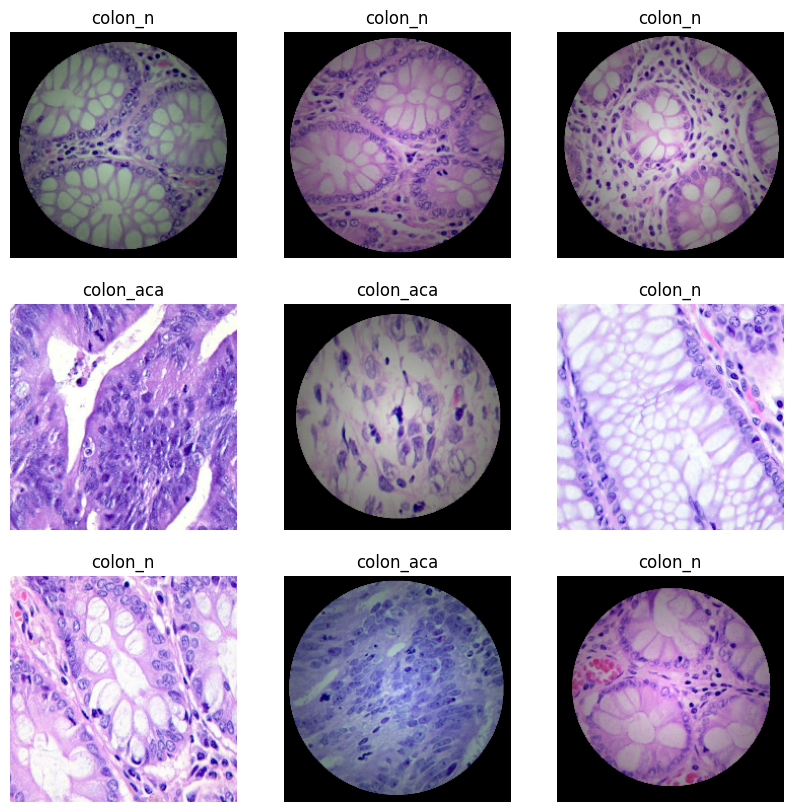

In [25]:
plt.figure(figsize=(10, 10))

for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)

        plt.imshow(images[i].numpy().astype("uint8"))

        plt.title(train_ds.class_names[labels[i]])
        plt.axis("off")

In [26]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

In [27]:
base_model.trainable = False

In [28]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.1),
])

In [29]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(224, 224, 3)),

    data_augmentation,

    tf.keras.layers.Lambda(
        tf.keras.applications.mobilenet_v2.preprocess_input
    ),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(2, activation="sigmoid")
])

In [30]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [31]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 29s 137ms/step - accuracy: 0.5919 - loss: 0.7819 - val_accuracy: 0.8881 - val_loss: 0.3237
Epoch 2/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 39s 128ms/step - accuracy: 0.9059 - loss: 0.2826 - val_accuracy: 0.9350 - val_loss: 0.2062
Epoch 3/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 26s 128ms/step - accuracy: 0.9307 - loss: 0.1961 - val_accuracy: 0.9506 - val_loss: 0.1571
Epoch 4/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 31s 154ms/step - accuracy: 0.9498 - loss: 0.1528 - val_accuracy: 0.9600 - val_loss: 0.1303
Epoch 5/5
200/200 ━━━━━━━━━━━━━━━━━━━━ 37s 186ms/step - accuracy: 0.9578 - loss: 0.1263 - val_accuracy: 0.9631 - val_loss: 0.1145


In [32]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │         2,562 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,265,672 (8.64 MB)

 Trainable params: 2,562 (10.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

 Optimizer params: 5,126 (20.03 KB)

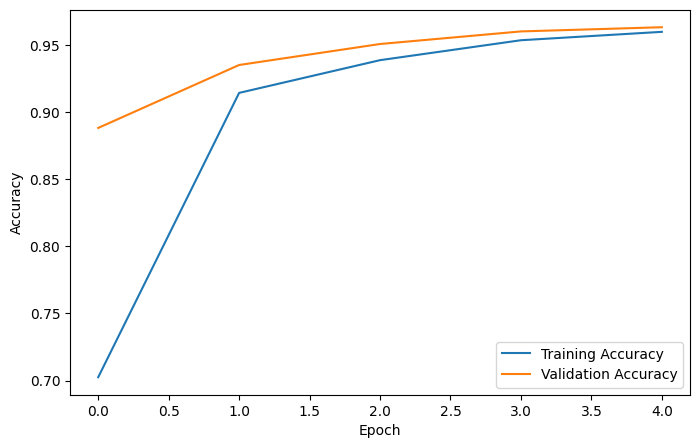

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

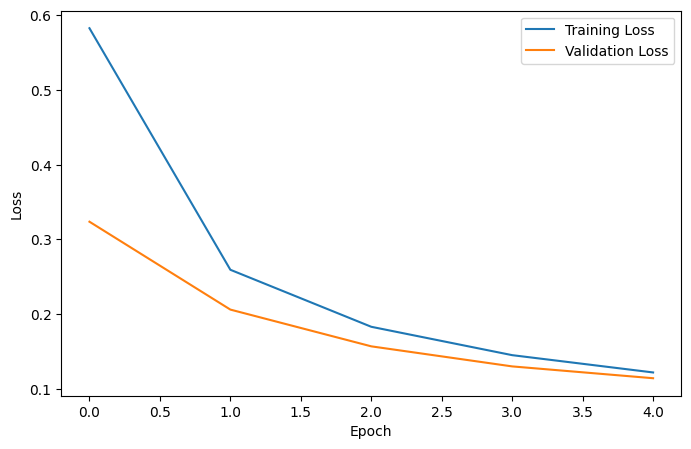

In [34]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [35]:
model.save(r"C:\Users\arif.arshad\Desktop\MicroAI\models\mix_2class.keras")

In [36]:
y_true = []
y_pred = []

for images, labels in clean_test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

y_true = np.array(y_true)
y_pred = np.array(y_pred)

class_names = clean_test_ds.class_names

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

   colon_aca     0.9688    0.9940    0.9812       500
     colon_n     0.9938    0.9680    0.9807       500

    accuracy                         0.9810      1000
   macro avg     0.9813    0.9810    0.9810      1000
weighted avg     0.9813    0.9810    0.9810      1000



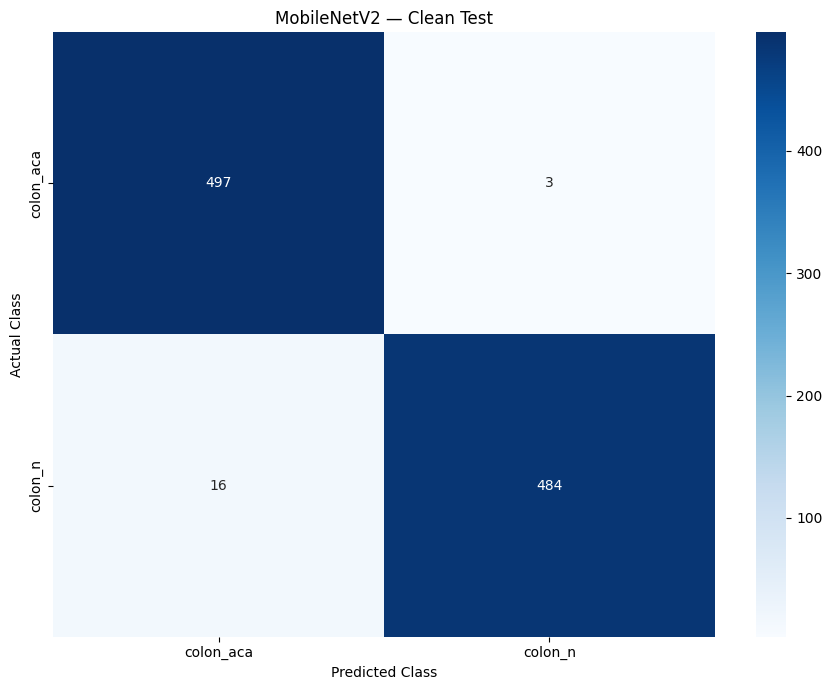

In [37]:
cm_ugly = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_ugly,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("MobileNetV2 — Clean Test")

plt.tight_layout()
plt.show()

In [38]:
y_true_ugly = []
y_pred_ugly = []

for images, labels in ugly_test_ds:

    predictions = model.predict(
        images,
        verbose=0
    )

    predicted_labels = np.argmax(
        predictions,
        axis=1
    )

    y_true_ugly.extend(labels.numpy())
    y_pred_ugly.extend(predicted_labels)

y_true_ugly = np.array(y_true_ugly)
y_pred_ugly = np.array(y_pred_ugly)

print(
    classification_report(
        y_true_ugly,
        y_pred_ugly,
        target_names=class_names,
        digits=4
    )
)

              precision    recall  f1-score   support

   colon_aca     0.9049    0.9700    0.9363       500
     colon_n     0.9677    0.8980    0.9315       500

    accuracy                         0.9340      1000
   macro avg     0.9363    0.9340    0.9339      1000
weighted avg     0.9363    0.9340    0.9339      1000



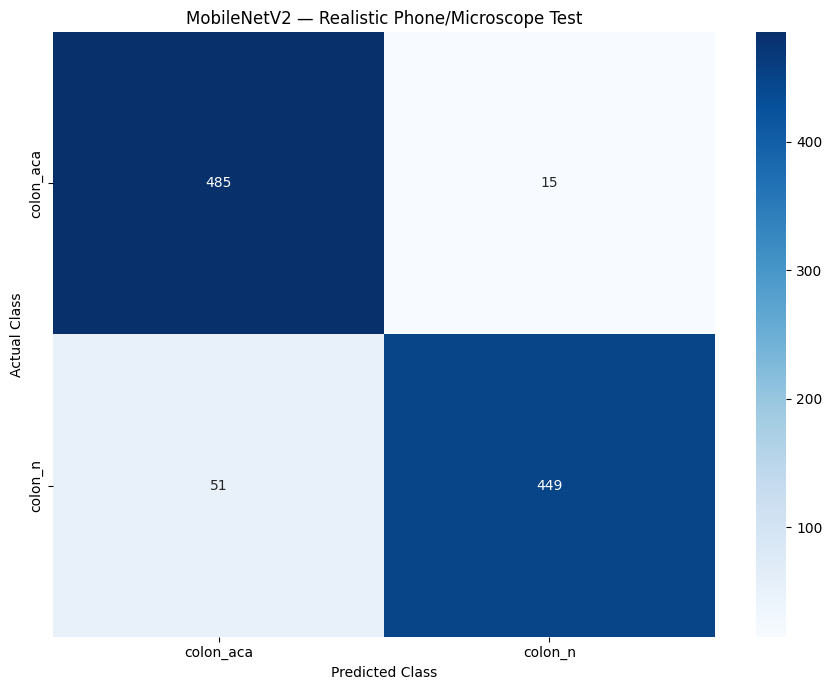

In [39]:
cm_ugly = confusion_matrix(
    y_true_ugly,
    y_pred_ugly
)

plt.figure(figsize=(9, 7))

sns.heatmap(
    cm_ugly,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("MobileNetV2 — Realistic Phone/Microscope Test")

plt.tight_layout()
plt.show()

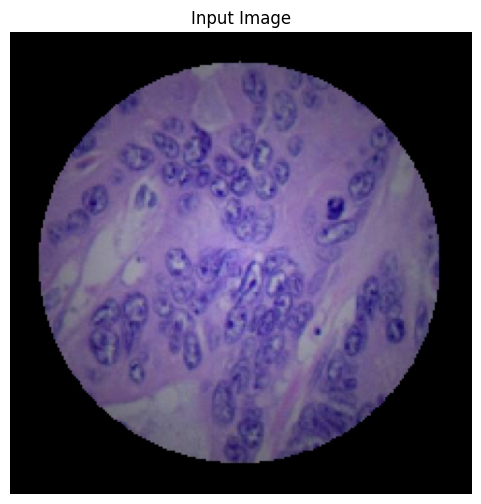


              MicroAI - Prediction

Image                : colonca4279.jpeg
Tissue               : Colon
Condition            : Cancerous
Specific class       : Colon Adenocarcinoma
Disease probability  : 88.43%
Model confidence     : 88.43%

-------------------------------------------------------
Class probabilities:
  Colon Adenocarcinoma : 88.43%
  Normal Colon         : 17.39%


In [43]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# IMAGE PATH
# ============================================================

IMAGE_PATH = r"C:\Users\arif.arshad\Desktop\MicroAI\test_ugly\colon_aca\colonca4279.jpeg"

# ============================================================
# CLASS INFORMATION
# ============================================================

class_names = ["colon_aca", "colon_n"]

# ============================================================
# LOAD IMAGE
# ============================================================

img = tf.keras.utils.load_img(
    IMAGE_PATH,
    target_size=(224, 224)
)

img_array = tf.keras.utils.img_to_array(img)
input_array = np.expand_dims(img_array, axis=0)

# ============================================================
# PREDICT
# ============================================================

predictions = model.predict(input_array, verbose=0)[0]

predicted_index = np.argmax(predictions)
predicted_class = class_names[predicted_index]
confidence = predictions[predicted_index] * 100

# ============================================================
# DISPLAY IMAGE
# ============================================================

plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title("Input Image")
plt.show()

# ============================================================
# INTERPRETATION
# ============================================================

tissue = "Colon"

if predicted_class == "colon_aca":
    condition = "Cancerous"
    specific_class = "Colon Adenocarcinoma"
    disease_probability = predictions[0] * 100
else:
    condition = "Non-cancerous"
    specific_class = "Normal Colon"
    disease_probability = 0.0

# ============================================================
# STRUCTURED OUTPUT
# ============================================================

print("\n" + "=" * 55)
print("              MicroAI - Prediction")
print("=" * 55)

print(f"\nImage                : {os.path.basename(IMAGE_PATH)}")
print(f"Tissue               : {tissue}")
print(f"Condition            : {condition}")
print(f"Specific class       : {specific_class}")
print(f"Disease probability  : {disease_probability:.2f}%")
print(f"Model confidence     : {confidence:.2f}%")

print("\n" + "-" * 55)
print("Class probabilities:")

print(
    f"  Colon Adenocarcinoma : "
    f"{predictions[0] * 100:.2f}%"
)

print(
    f"  Normal Colon         : "
    f"{predictions[1] * 100:.2f}%"
)

print("=" * 55)